In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import utils as uti
import visualizacoes as vis
import analise_descritiva as ad
import limpeza as lpz
import outliers as out
import imputacao as imp
import format as frm  

# Gráficos de barras para comparação de resultados

Eu quero gerar um gráfico de barras para cada base de dados. Cada barra deve representar uma variável. Acho que a ideia é comparar o grau de complexão entre cada método? Pensando agora, se esse for o objetivo, acho que a matrix da biblioteca missingno já faça isso melhor

In [7]:
from utils import dados

dados_brutos, metadados, variaveis = dados(r"data\input\dados_brutos.xlsx")
dados_prontos, metadados, variaveis = dados(r"data\out\dados_prontos.xlsx")
dados_limpos, metadados, variaveis = dados(r"data\out\dados_limpos.xlsx")
remocao_zscore, metadados, variaveis = dados(r"data\out\limpos_zscore.xlsx")
remocao_iqr, metadados, variaveis = dados(r"data\out\limpos_iqr.xlsx")
limpos_imput_media, metadados, variaveis = dados(r"data\out\limpos_mean.xlsx")
limpos_imput_mediana, metadados, variaveis = dados(r"data\out\limpos_mediana.xlsx")
limpos_imput_knn, metadados, variaveis = dados(r"data\out\limpos_knn.xlsx")
zscore_imput_media, metadados, variaveis = dados(r"data\out\zscore_mean.xlsx")
zscore_imput_mediana, metadados, variaveis = dados(r"data\out\zscore_mediana.xlsx")
zscore_imput_knn, metadados, variaveis = dados(r"data\out\zscore_knn.xlsx")
iqr_imput_media, metadados, variaveis = dados(r"data\out\iqr_mean.xlsx")
iqr_imput_mediana, metadados, variaveis = dados(r"data\out\iqr_mediana.xlsx")
iqr_imput_knn, metadados, variaveis = dados(r"data\out\iqr_knn.xlsx")

In [8]:
variaveis = []

for variavel in dados_prontos.columns:
    variaveis.append(variavel)

# for variavel in dados_limpos.columns:
#     variaveis.append(variavel)

from utils import METADADOS

for metadado in METADADOS:
    variaveis.remove(metadado)

data_bases = [dados_brutos, dados_prontos, dados_limpos, 
              remocao_zscore, remocao_iqr, 
              limpos_imput_media, limpos_imput_mediana, limpos_imput_knn, 
              zscore_imput_media, zscore_imput_mediana, zscore_imput_knn, 
              iqr_imput_media, iqr_imput_mediana, iqr_imput_knn]

In [ ]:
for base in data_bases:
    for variavel in variaveis:
        try:
            sns.barplot(data=base,
                        x=base[variavel],
                        y=variavel)
        except ValueError:
            pass

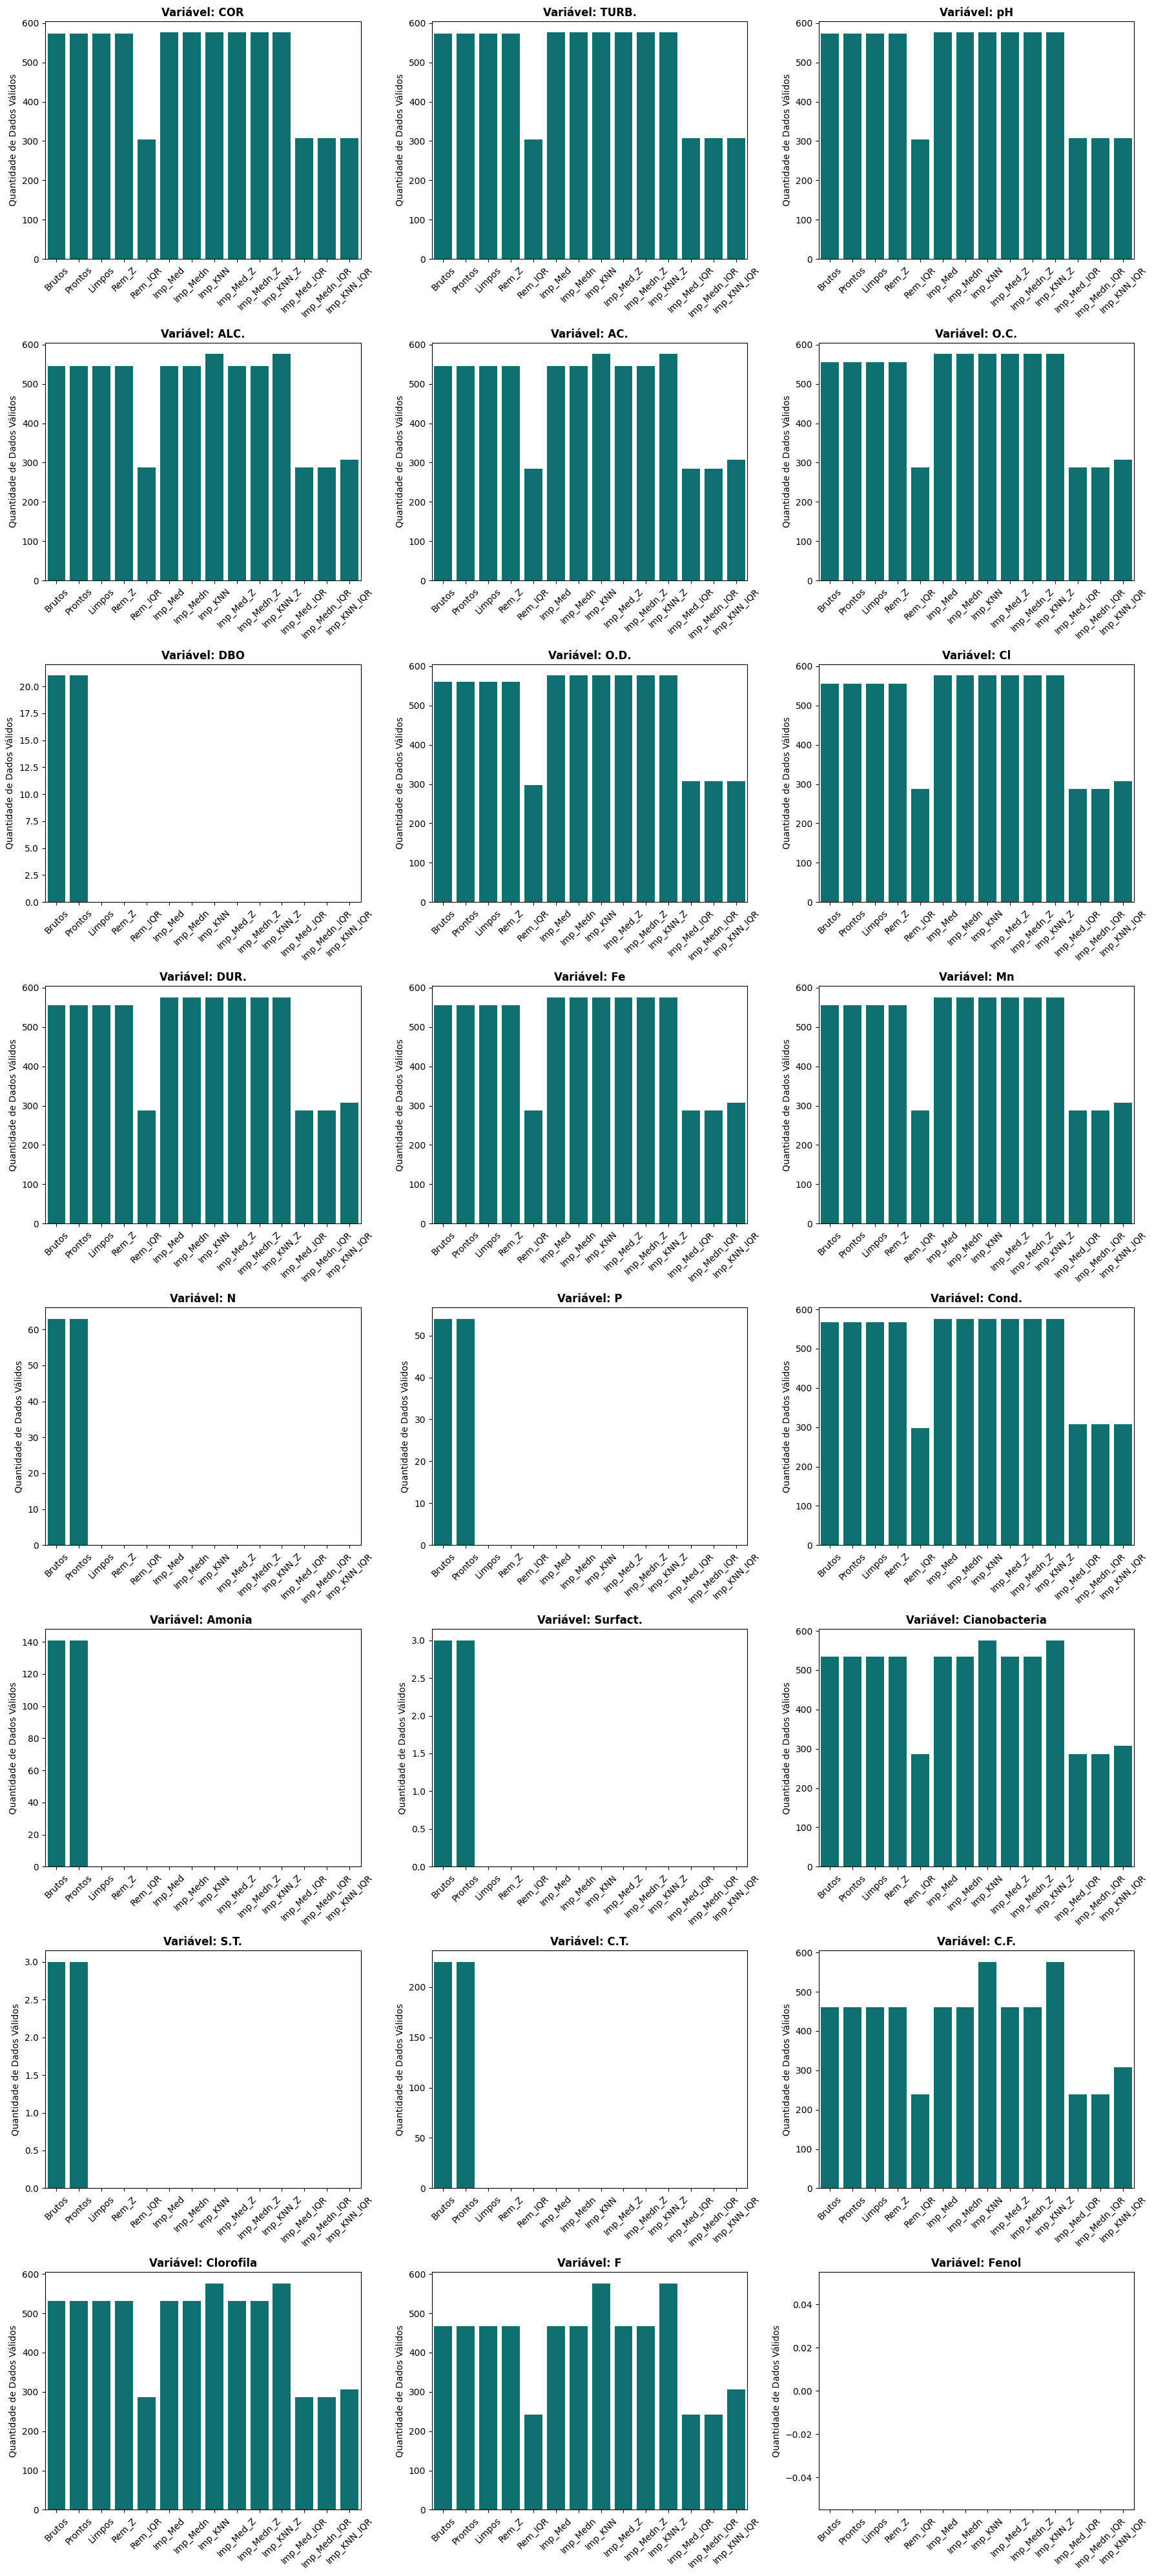

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Criar nomes curtos para as 14 bases de dados (para ficar legível no gráfico)
nomes_bases = [
    'Brutos', 'Prontos', 'Limpos', 'Rem_Z', 'Rem_IQR', 
    'Imp_Med', 'Imp_Medn', 'Imp_KNN', 
    'Imp_Med_Z', 'Imp_Medn_Z', 'Imp_KNN_Z', 
    'Imp_Med_IQR', 'Imp_Medn_IQR', 'Imp_KNN_IQR'
]

# 2. Criar um dicionário para armazenar as contagens
# O formato será: {'Nome_da_Variavel': [contagem_base1, contagem_base2, ..., contagem_base14]}
resumo_contagens = {}

for variavel in variaveis:
    contagens_desta_variavel = []
    
    for base in data_bases:
        # Verifica se a variável ainda existe na base de dados
        if variavel in base.columns:
            # pd.to_numeric com errors='coerce' transforma textos como ">8000" em dados faltantes (NaN)
            # Em seguida, o .count() conta apenas os dados numéricos válidos (ignora os NaN)
            coluna_numerica = pd.to_numeric(base[variavel], errors='coerce')
            qtd_validos = coluna_numerica.count()
        else:
            # Se a coluna foi removida durante a limpeza, a contagem é 0
            qtd_validos = 0
            
        contagens_desta_variavel.append(qtd_validos)
        
    resumo_contagens[variavel] = contagens_desta_variavel

# 3. Configurar a grande figura (Grid) de gráficos
num_variaveis = len(variaveis)
colunas_no_grafico = 3 # Quantidade de gráficos lado a lado
# Calcula quantas linhas serão necessárias com base na quantidade de variáveis
linhas_no_grafico = math.ceil(num_variaveis / colunas_no_grafico) 

# Cria a figura grande. O figsize ajusta o tamanho (largura, altura)
fig, axes = plt.subplots(linhas_no_grafico, colunas_no_grafico, figsize=(18, 5 * linhas_no_grafico))

# Transforma a matriz de espaços de gráficos em uma lista simples para facilitar o loop
axes = axes.flatten()

# 4. Gerar um gráfico de barras para cada variável
for i, variavel in enumerate(variaveis):
    # Pega o espaço (eixo) específico para este gráfico
    ax = axes[i]
    
    # Desenha o gráfico de barras
    sns.barplot(x=nomes_bases, y=resumo_contagens[variavel], ax=ax, color='teal')
    
    # Configurações de estética do gráfico menor
    ax.set_title(f'Variável: {variavel}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade de Dados Válidos')
    ax.tick_params(axis='x', rotation=45) # Inclina os nomes das bases para não sobrepor

# 5. Limpar espaços vazios (se o número de variáveis não preencher a última linha perfeitamente)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajusta o espaçamento para que os textos e gráficos não fiquem colados uns nos outros
plt.tight_layout()
plt.show()

In [ ]:
# Referências para essa tentativa:
### https://www.statology.org/seaborn-multiple-plots/
### https://stackoverflow.com/questions/64145095/how-to-plot-data-from-multiple-dataframes-with-seaborn-relplot

variaveis = []
for variavel in dados_prontos.columns:
    variaveis.append(variavel)

for metadado in METADADOS:
    variaveis.remove(metadado)

data_bases = [dados_brutos, dados_prontos, dados_limpos, 
              remocao_z_score, remocao_iqr, 
              imput_media, imput_mediana, imput_KNN, 
              imput_media_zscore, imput_mediana_zscore, imput_KNN_zscore, 
              imput_media_iqr, imput_mediana_iqr, imput_KNN_iqr]

df = pd.DataFrame

df = pd.concat(data_bases[0], data_bases[1], data_bases[2], data_bases[3],
               data_bases[4], data_bases[5], data_bases[6], data_bases[7],
               data_bases[8], data_bases[9], data_bases[10], data_bases[11],
               data_bases[12], data_bases[13])

df

TypeError: concat() takes 1 positional argument but 14 were given

In [ ]:
# Referências para essa tentativa:
### https://www.statology.org/seaborn-multiple-plots/
### https://stackoverflow.com/questions/64145095/how-to-plot-data-from-multiple-dataframes-with-seaborn-relplot

variaveis = []
for variavel in dados_prontos.columns:
    variaveis.append(variavel)

for metadado in METADADOS:
    variaveis.remove(metadado)

data_bases = [dados_brutos, dados_prontos, dados_limpos, 
              remocao_z_score, remocao_iqr, 
              imput_media, imput_mediana, imput_KNN, 
              imput_media_zscore, imput_mediana_zscore, imput_KNN_zscore, 
              imput_media_iqr, imput_mediana_iqr, imput_KNN_iqr]



TypeError: concat() takes 1 positional argument but 14 were given